## TODO:  HEADER

In [1]:
%load_ext autoreload
%autoreload 2

import nltk

nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

import pandas as pd
import matplotlib.pyplot as plt

from utils.preprocess import text_cleaner, pipeline
from utils.encoders import *
from lingua import LanguageDetectorBuilder
from deep_translator import GoogleTranslator
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
c:\Users\egorm\miniconda3\envs\tm_masters\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


# EDA

In [2]:
train_full = pd.read_csv(r"data/train.csv")
train, validation = train_test_split(train_full, test_size=0.2, stratify=train_full.label)
test = pd.read_csv(r"data/test.csv", index_col=0)
display(train.sample(3))
display(validation.sample(3))
test.sample(3)

,text,label
1738,NOVONIX : BTS WINS DISCOVERY AWARD FOR INNOVAT...,2
957,Brazilian food delivery app iFood looks to gro...,1
352,WestRock upgraded to buy from neutral at BofA ...,1


,text,label
62,"Earnings Update: electroCore, Inc. Just Report...",0
4117,"Among Largest US Markets, Most Demand Is Still...",2
8103,This $3B biotech has been a three-bagger since...,1


,text
id,
2384,"Domtar EPS misses by $0.05, revenue in-line"
2352,Edited Transcript of WIZZ.L earnings conferenc...
326,Passing The Torch … Or Should I Say The Flashl...


## general

In [3]:
display(train.describe())
train.describe(include="str")

,label
count,7634.000000
mean,1.496201
std,0.743229
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,2.000000


,text
count,7634
unique,7634
top,"Is There An Opportunity With HealthEquity, Inc..."
freq,1


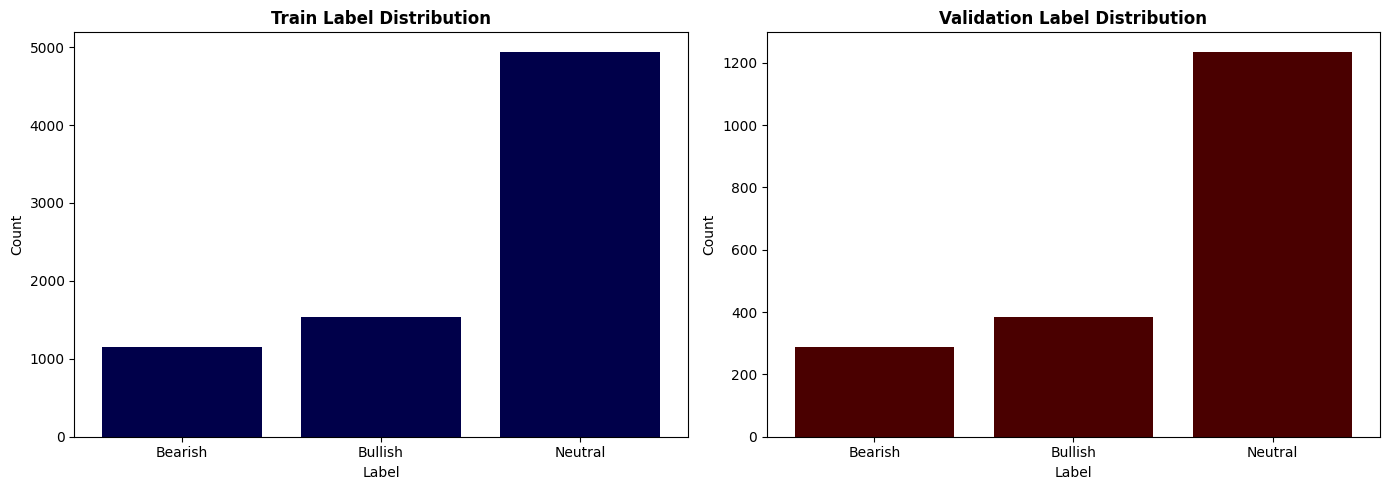

In [4]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(x = ["Bearish", "Bullish", "Neutral"],
        height=train.groupby("label")["text"].count().to_list(), # order by 0, 1, 2
        color="#00004A",
        )

ax[1].bar(x = ["Bearish", "Bullish", "Neutral"],
        height=validation.groupby("label")["text"].count().to_list(), # order by 0, 1, 2
        color="#4A0000",
        )

ax[0].set_xlabel("Label")
ax[0].set_ylabel("Count")
ax[0].set_title(
    "Train Label Distribution", fontweight="bold"
)

ax[1].set_xlabel("Label")
ax[1].set_ylabel("Count")
ax[1].set_title(
    "Validation Label Distribution", fontweight="bold"
)

plt.tight_layout()
plt.savefig(r"plots/correct_split.png")
plt.show()

## Text Overview

### Raw

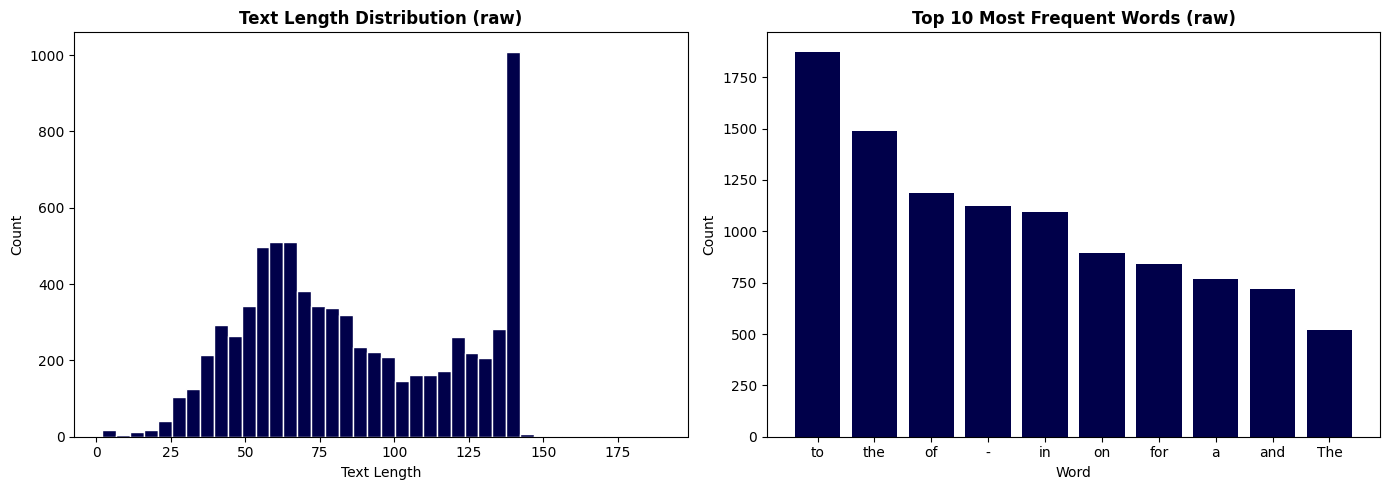

In [5]:
freq_raw = pd.Series(' '.join(train['text']).split()).value_counts()

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].hist(
         train.text.str.len(),
         bins=40,
         color="#00004A",
         edgecolor="white"
         )

ax[1].bar(freq_raw.head(10).index, freq_raw.head(10).values, color="#00004A")

ax[0].set_xlabel("Text Length")
ax[0].set_ylabel("Count")
ax[0].set_title("Text Length Distribution (raw)", fontweight="bold")
ax[1].set_xlabel("Word")
ax[1].set_ylabel("Count")
ax[1].set_title("Top 10 Most Frequent Words (raw)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"plots/raw_distributions.png")
plt.show()

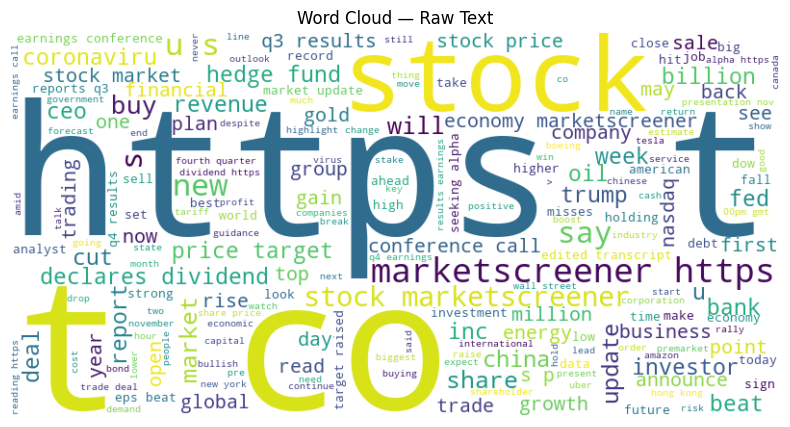

In [6]:
raw_text = ' '.join(train['text']).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Raw Text')
plt.savefig(r"plots/raw_wordcloud.png")
plt.show()

### Cleaning

In [7]:
train["text_clean"] = text_cleaner(train.text)
validation["text_clean"] = text_cleaner(validation.text)

display(train.sample(5))
validation.sample(5)

,text,label,text_clean
6002,Delta's private jet business to gain equity st...,2,delta private jet business to gain equity stak...
711,The NY Fed said it accepted $25 billion in bid...,2,the ny fed said it accepted 25 billion in bids...
2129,A troubled Chinese state-own firm is giving bo...,2,a troubled chinese state own firm is giving bo...
3467,Kellogg Q4 EPS 42 cents vs. per-share loss 24 ...,1,kellogg q4 eps 42 cents vs per share loss 24 c...
4056,A Montreal satellite company makes a major bre...,2,a montreal satellite company makes a major bre...


,text,label,text_clean
8365,6 Guru Stocks Expanding Earnings,2,6 guru stocks expanding earnings
512,China still has room for conventional monetary...,2,china still has room for conventional monetary...
7093,"The latest pre-open #analysis of #news, #data ...",2,the latest pre open analysis of news data driv...
837,Nike Warns Coronavirus Is Presuring Sales in C...,0,nike warns coronavirus is presuring sales in c...
9194,$KHC (+4.2% pre) Kraft Heinz stock rises on ex...,1,STOCK 4 2 percent pre kraft heinz stock rises ...


In [8]:
detector = LanguageDetectorBuilder.from_all_languages().build()

languages_train = detector.detect_languages_in_parallel_of(train.text_clean)
train["language"] = [lang.name.lower() if lang else None for lang in languages_train]

languages_validation = detector.detect_languages_in_parallel_of(validation.text_clean)
validation["language"] = [lang.name.lower() if lang else None for lang in languages_validation]

non_eng_train = train[train["language"]!="english"]["text_clean"].index.to_list()
non_eng_validation = validation[validation["language"]!="english"]["text_clean"].index.to_list()

train.sample(5)
validation.sample(5)

,text,label,text_clean,language
5425,We Shouldn’t Strip U.S. Terrorists of Citizenship,2,we should not strip you s terrorists of citize...,english
8891,What Does Minth Group Limited's (HKG:425) Shar...,2,what does minth group limited hkg 425 share pr...,english
4058,A New Problem for Clean Energy: Dealing With O...,2,a new problem for clean energy dealing with ol...,english
1925,TD sees no rate hikes by G-10 central banks ne...,2,td sees no rate hikes by gminus10 central bank...,english
6223,Japan declares state of emergency #economy #Ma...,0,japan declares state of emergency economy mark...,english


In [9]:
# GoogleTranslator sometimes adds symbols on its own, so has to be cleaned again even if use text_clean
# TODO use text_clean or text?

train.loc[non_eng_train, "text_clean"] = text_cleaner(
    pd.Series(
        GoogleTranslator().translate_batch(
            train.loc[non_eng_train, "text"].to_list()
                                        )
            )
    ).to_list()

validation.loc[non_eng_validation, "text_clean"] = text_cleaner(
    pd.Series(
        GoogleTranslator().translate_batch(
            validation.loc[non_eng_validation, "text"].to_list()
                                        )
            )
    ).to_list()

In [10]:
# TODO: change stopwords as Bea said
train["text_tokens"] = pipeline(train["text_clean"], to_clean=False)
validation["text_tokens"] = pipeline(validation["text_clean"], to_clean=False)

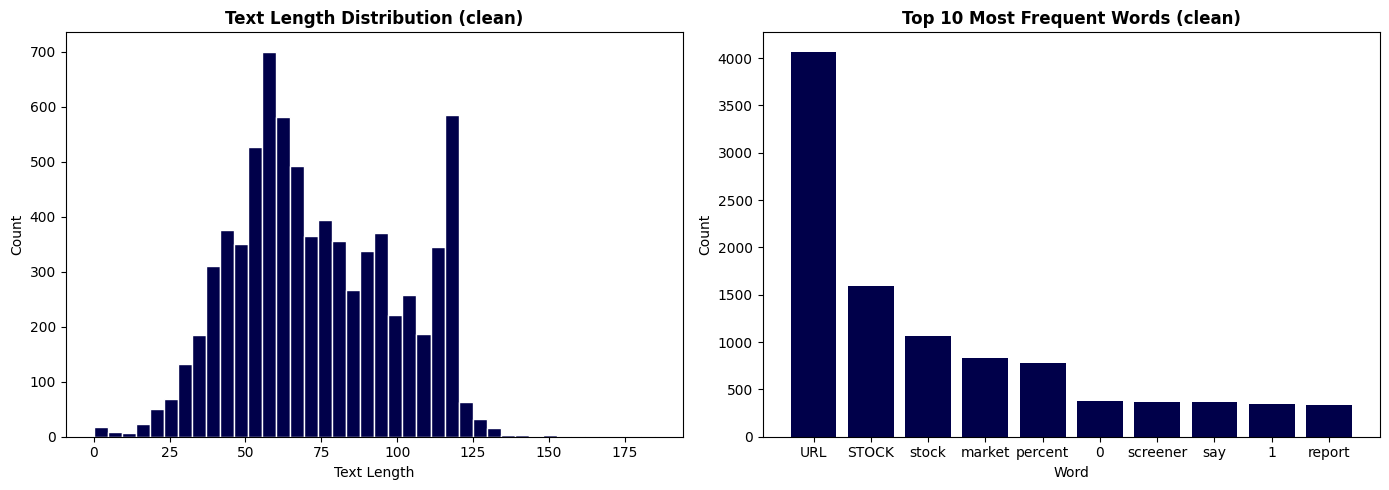

In [11]:
train["text_clean_joined"] = train['text_tokens'].apply(lambda x: " ".join(x))
freq_clean = pd.Series(' '.join(train['text_clean_joined']).split()).value_counts()

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))
ax[0].hist(
         train.text_clean.str.len(),
         bins=40,
         color="#00004A",
         edgecolor="white"
         )
ax[1].bar(freq_clean.head(10).index, freq_clean.head(10).values, color="#00004A")

ax[0].set_xlabel("Text Length")
ax[0].set_ylabel("Count")
ax[0].set_title("Text Length Distribution (clean)", fontweight="bold")
ax[1].set_xlabel("Word")
ax[1].set_ylabel("Count")
ax[1].set_title("Top 10 Most Frequent Words (clean)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"plots/clean_distributions.png")
plt.show()

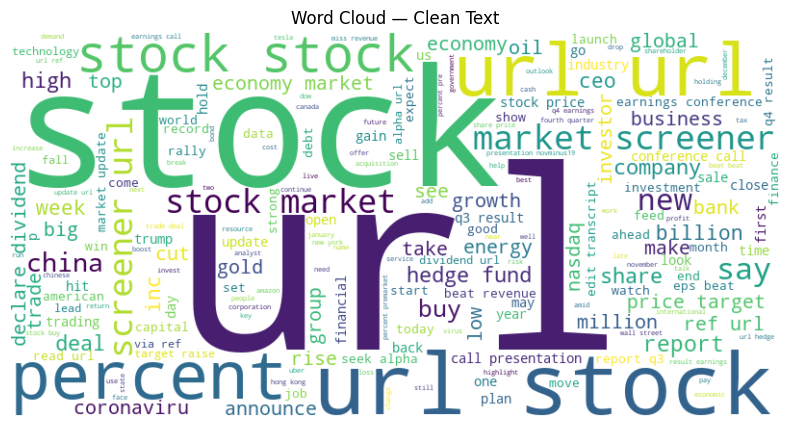

In [12]:
raw_text = ' '.join(train["text_clean_joined"]).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Clean Text')
plt.savefig(r"plots/clean_wordcloud.png")
plt.show()

### Encoding
todo: should there be umap?

In [13]:
train_bow = encode_bow(train["text_tokens"])
train_vec = ...
train_trans = ...

train_label = train["label"]

In [14]:
validation_bow = encode_bow(validation["text_tokens"])
validation_vec = ...
validation_trans = ...

validation_label = validation["label"]

## Training